In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("card_transdata.csv")

In [3]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1,1,0,0,0
1,10.829943,0.175592,1.294219,1,0,0,0,0
2,5.091079,0.805153,0.427715,1,0,0,1,0
3,2.247564,5.600044,0.362663,1,1,0,1,0
4,44.190936,0.566486,2.222767,1,1,0,1,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   distance_from_home              1999 non-null   float64
 1   distance_from_last_transaction  1999 non-null   float64
 2   ratio_to_median_purchase_price  1999 non-null   float64
 3   repeat_retailer                 1999 non-null   int64  
 4   used_chip                       1999 non-null   int64  
 5   used_pin_number                 1999 non-null   int64  
 6   online_order                    1999 non-null   int64  
 7   fraud                           1999 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 125.1 KB


In [5]:
df.isnull().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

# EDA

In [7]:
df.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000
mean,25.648283,5.618399,1.740063,0.897449,0.327164,0.107554,0.663332,0.088544
std,55.483678,33.588895,2.520772,0.303448,0.469295,0.309894,0.472689,0.284156
min,0.104184,0.001448,0.016933,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.088613,0.313035,0.491031,1.000000,0.000000,0.000000,0.000000,0.000000
50%,10.156363,1.049895,0.994040,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.456212,3.313595,2.002841,1.000000,1.000000,0.000000,1.000000,0.000000
max,965.910612,990.070315,41.023449,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.corr()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
distance_from_home,1.000000,-0.018671,-0.010039,0.149494,-0.025663,0.000593,0.031725,0.248342
distance_from_last_transaction,-0.018671,1.000000,-0.004593,0.015590,-0.006400,-0.018269,-0.002435,0.085563
ratio_to_median_purchase_price,-0.010039,-0.004593,1.000000,0.024582,0.024875,-0.027212,0.020929,0.491860
repeat_retailer,0.149494,0.015590,0.024582,1.000000,0.017814,0.016225,0.010409,0.029902
used_chip,-0.025663,-0.006400,0.024875,0.017814,1.000000,-0.042469,0.036508,-0.059706
used_pin_number,0.000593,-0.018269,-0.027212,0.016225,-0.042469,1.000000,-0.043107,-0.108202
online_order,0.031725,-0.002435,0.020929,0.010409,0.036508,-0.043107,1.000000,0.207144
fraud,0.248342,0.085563,0.491860,0.029902,-0.059706,-0.108202,0.207144,1.000000


# visualization

<Axes: >

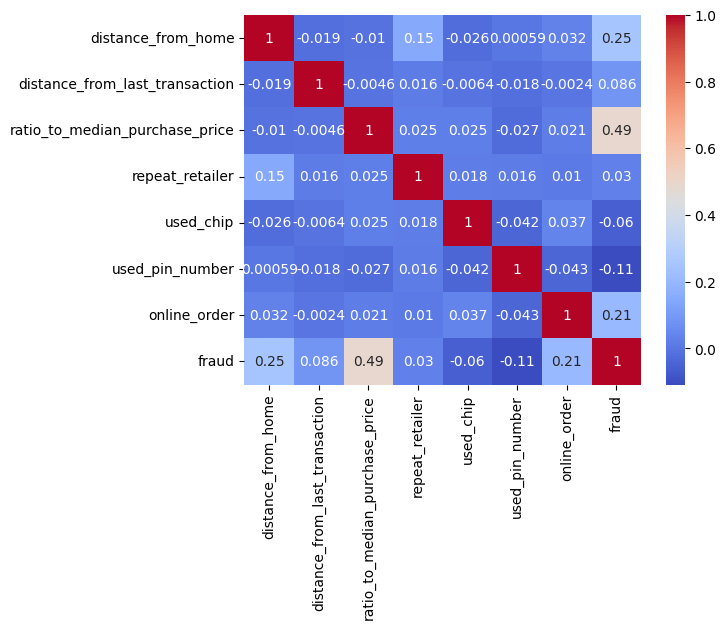

In [9]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

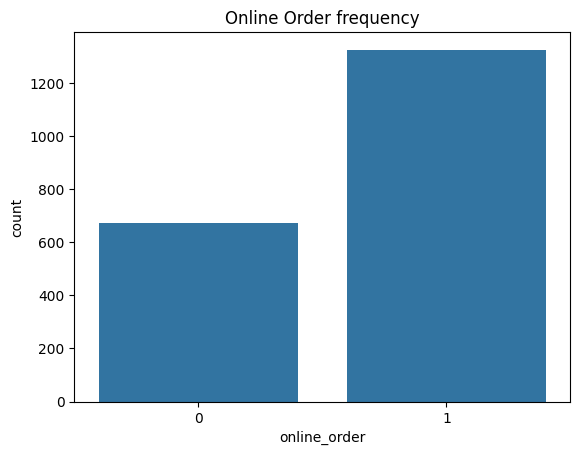

In [10]:
sns.countplot(data=df,x='online_order')
plt.title('Online Order frequency')
plt.show()

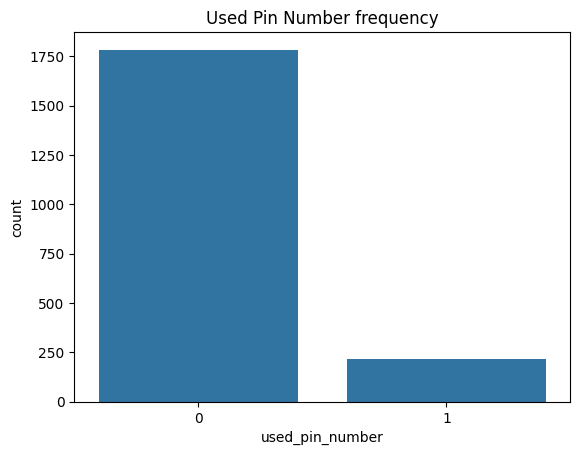

In [11]:
sns.countplot(data=df,x='used_pin_number')
plt.title('Used Pin Number frequency')
plt.show()

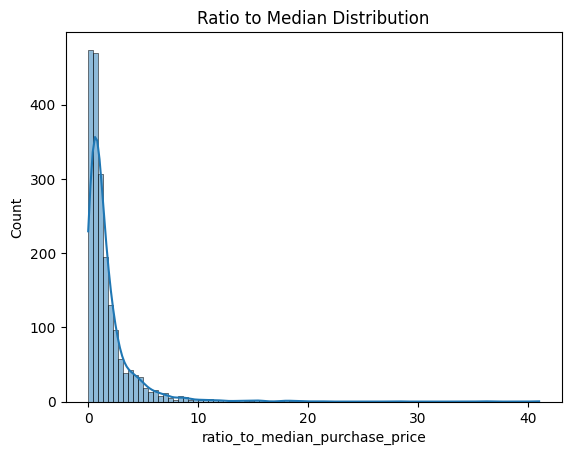

In [12]:
sns.histplot(df['ratio_to_median_purchase_price'],kde='True')
plt.title('Ratio to Median Distribution')
plt.show()

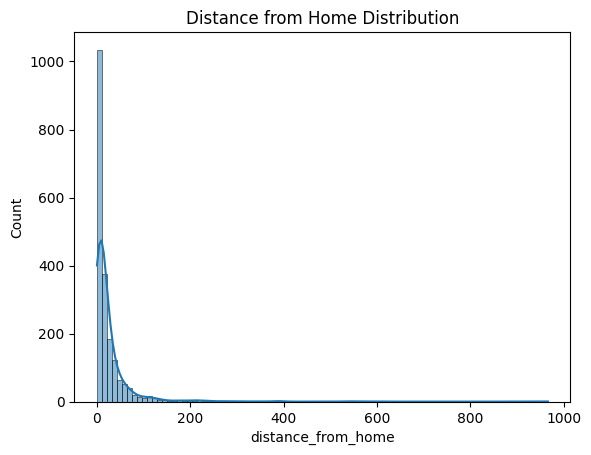

In [13]:
sns.histplot(df['distance_from_home'],kde='True')
plt.title('Distance from Home Distribution')
plt.show()

# machine learning model

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [15]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1,1,0,0,0
1,10.829943,0.175592,1.294219,1,0,0,0,0
2,5.091079,0.805153,0.427715,1,0,0,1,0
3,2.247564,5.600044,0.362663,1,1,0,1,0
4,44.190936,0.566486,2.222767,1,1,0,1,0


In [16]:
x=df.iloc[:,[0,2,5,6]].values
y=df['fraud'].values

In [17]:
#standardising independent variables
scaler=StandardScaler()
x_stand=scaler.fit_transform(x)
df_x_comp=pd.DataFrame(x_stand[0:5,0],x[0:5,0])
df_x_comp.reset_index(inplace=True)
df_x_comp.columns=['x','x_stand']
df_x_comp


,x,x_stand
0,57.877857,0.581029
1,10.829943,-0.267142
2,5.091079,-0.370602
3,2.247564,-0.421864
4,44.190936,0.334284


# using pickle to save scaler so that we can save mean and std of the data

In [34]:
import pickle
with open('credit_card_scaler.pkl','wb') as f:
     pickle.dump(scaler,f)


In [18]:
x_train, x_test, y_train, y_test = train_test_split(x_stand, y, test_size=0.2, random_state=42)

In [19]:
classifier = LogisticRegression()
classifier.fit(x_train, y_train)
y_pred=classifier.predict(x_test)

# using pickle to load the model

In [36]:
import pickle
with open('credit_card_model.pkl', 'wb') as f:
    pickle.dump(classifier,f)

# metrics

In [20]:
coefficients=pd.DataFrame({'feature':df.columns[[0,2,5,6]],'coefficient':classifier.coef_[0]})
coefficients

,feature,coefficient
0,distance_from_home,0.915342
1,ratio_to_median_purchase_price,2.487668
2,used_pin_number,-1.426489
3,online_order,3.248406


In [21]:
#accuracy_score
accuracy_score(y_test,y_pred)

0.965

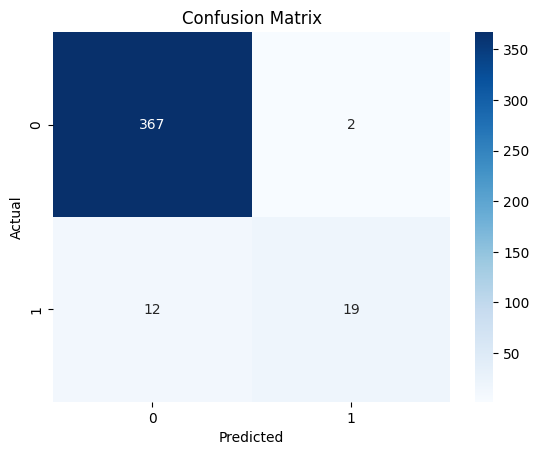

In [22]:
#confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       369
           1       0.90      0.61      0.73        31

    accuracy                           0.96       400
   macro avg       0.94      0.80      0.86       400
weighted avg       0.96      0.96      0.96       400



# random forest

In [24]:
classifier_rf=RandomForestClassifier(n_estimators=100, random_state=42)
classifier_rf.fit(x_train, y_train)
y_pred_rf=classifier_rf.predict(x_test)

# metrics for random forest

In [25]:
#accuracy_score
accuracy_score(y_test,y_pred_rf)

0.98

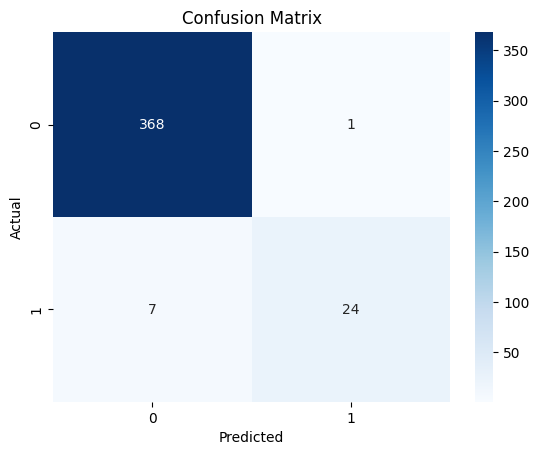

In [26]:
#confusion matrix 
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
#classification report
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       369
           1       0.96      0.77      0.86        31

    accuracy                           0.98       400
   macro avg       0.97      0.89      0.92       400
weighted avg       0.98      0.98      0.98       400

